# QGIS 8-Class Segmentation — Pipeline A: Fine-tune from Winter Checkpoint

This notebook implements **Pipeline A (Phase 2)** for fine-tuning a winter-trained model on summer imagery using a season curriculum.

**Training Phases:**
- **Phase 1** (completed separately): Winter-only training → saves `best.pth`
- **Phase 2** (THIS notebook): Load Phase 1 checkpoint → fine-tune with summer data using curriculum
- **Phase 3** (optional): Resume interrupted Phase 2 run from `latest.pth`

**Key Features:**
- Season curriculum: 80% winter → 50/50 → 20% → 10% winter over 10 epochs
- Triple validation sets: combined-val, winter-val, summer-val (monitor forgetting vs. adaptation)
- Loads Phase 1 winter checkpoint weights (model only, fresh optimizer)
- CSV-based dataset mixing winter/summer images per tile
- Per-run folders, full checkpointing, CSV logging, early stopping

**Run cells in order. Main training is near the end.**

## ⚙️ Quick Setup Guide

**Training Phases Overview:**
1. **Phase 1 - Winter Training** (separate run, already completed): Train on winter-only imagery → saves `best.pth`
2. **Phase 2 - Pipeline A Fine-tuning** (this notebook): Load winter checkpoint → train with season curriculum → adapt to summer
3. **Phase 3 - Resume (optional)**: If interrupted, can resume Phase 2 from where it stopped

**Before running, configure these key parameters:**

1. **Winter Checkpoint** (Cell 6): Set `WINTER_CHECKPOINT_PATH` to your Phase 1 winter training's `best.pth`
2. **Season Curriculum** (Cell 6): Adjust epoch ranges and winter/summer mix ratios (default: 80%→50%→20%→10%)
3. **Fine-Tuning LRs** (Cell 6): Set encoder/decoder learning rates (default: 100× and 50× higher than winter-end)
4. **Training Duration** (Cell 6): Set `FINETUNE_EPOCHS` (Pipeline A suggests 10)
5. **Resume Run** (Cell 20): Set `RESUME_RUN_NAME = None` for new Pipeline A run, or set to existing run folder name to resume

**Then run cells in order from top to bottom.**

In [23]:
# Imports (all at top, no local imports elsewhere)
import os
import sys
import json
import time
import datetime
import csv
import random
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib
try:
    matplotlib.use('module://matplotlib_inline.backend_inline')
except Exception:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import jaccard_score, accuracy_score, confusion_matrix
from PIL import Image
from tqdm import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
import seaborn as sns
import shutil, subprocess
import gc

torch.cuda.empty_cache()
torch.cuda.synchronize()
gc.collect()
print("GPU cache cleared")

GPU cache cleared


In [2]:
# Device and deterministic settings
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = True
print('Using device:', device)
if torch.cuda.is_available():
    try:
        print('device name:', torch.cuda.get_device_name(0))
    except Exception as e:
        print('get_device_name failed:', e)

Using device: cuda
device name: NVIDIA GeForce RTX 5050 Laptop GPU


## Fine-Tuning Configuration (Pipeline A)

**Configure these parameters before running:**

In [3]:
# ============================================================
# PIPELINE A: FINE-TUNING CONFIGURATION (MODIFY THESE!)
# ============================================================

# 1. Winter Checkpoint (best model from winter-only training)
# This should point to your COMPLETED winter training run's best checkpoint
# Example: if winter training saved to runs/20250315_120000/, use that path
WINTER_CHECKPOINT_PATH = Path(r"C:\Users\emilj\Documents\Thesis\TRAINING\runs\20260304_222309\best.pth")  # <-- UPDATE THIS PATH!
LOAD_WINTER_WEIGHTS = True  # Set False to train from scratch (not Pipeline A)

# 2. Season Curriculum Schedule (epoch ranges and winter/summer mix)
# Format: (start_epoch, end_epoch, winter_probability)
SEASON_CURRICULUM = [
    (0, 5,   0.80),  # Epochs 1-2: 80% winter, 20% summer (start safe)
    (5, 15,   0.50),  # Epochs 3-6: 50% winter, 50% summer (balanced)
    (15, 20,  0.20),  # Epochs 7-10: 20% winter, 80% summer (emphasize summer)
    (20, 80, 0.10),  # Epochs 11+: 0% winter, 100% summer (maintain winter knowledge)
]

# 3. Fine-Tuning Learning Rates (higher than end-of-winter-training)
# Rule of thumb: 5×-20× higher than the LR at epoch ~30 of winter run
# Winter run ended with ~1e-6 encoder, ~1e-5 decoder (after cosine decay)
FINETUNE_LR_ENCODER = 1e-4   # 100× higher than winter-end (aggressive adaptation)
FINETUNE_LR_DECODER = 5e-4   # 50× higher than winter-end

# 4. Training Duration
FINETUNE_EPOCHS = 25  # Pipeline A suggests 10 epochs for curriculum
PATIENCE = 15         # Early stop patience (epochs without improvement)

# 5. Dual Validation Sets (monitor forgetting vs. adaptation)
VAL_RATIO = 0.2              # 20% of tiles for validation
VAL_WINTER_PROB = 1.0        # winter-val uses 100% winter images
VAL_SUMMER_PROB = 0.0        # summer-val uses 100% summer images (0% winter)

# 6. Hard-Tile Weighting (optional, for epoch 3+)
ENABLE_HARD_TILE_WEIGHTING = False  # Set True after first 2 epochs
HARD_TILE_WEIGHT_MULTIPLIER = 5.0   # Oversample difficult tiles 5×

print("✓ Pipeline A configuration loaded")
print(f"  Winter checkpoint: {WINTER_CHECKPOINT_PATH}")
print(f"  Season curriculum: {len(SEASON_CURRICULUM)} phases over {FINETUNE_EPOCHS} epochs")
print(f"  Fine-tune LR: encoder={FINETUNE_LR_ENCODER:.1e}, decoder={FINETUNE_LR_DECODER:.1e}")
print(f"  Dual validation: winter-val (100% winter) + summer-val (100% summer)")

✓ Pipeline A configuration loaded
  Winter checkpoint: C:\Users\emilj\Documents\Thesis\TRAINING\runs\20260304_222309\best.pth
  Season curriculum: 4 phases over 25 epochs
  Fine-tune LR: encoder=1.0e-04, decoder=5.0e-04
  Dual validation: winter-val (100% winter) + summer-val (100% summer)


In [4]:
# Configuration: dataset paths and legend parsing
BASE_DIR = Path(r'C:/Users/emilj/Documents/Thesis/TRAINING/6Class_Dataset_Zoom_16_Rev3')
MASK_DIR = BASE_DIR / 'mask'
SATELLITE_DIR = BASE_DIR / 'aerial'
LEGEND_FILE = BASE_DIR / 'legend.txt'
CLASS_NAMES = []
COLOR_TO_CLASS = {}
COLOR_MAP = {}
with open(LEGEND_FILE, 'r') as f:
    for idx, line in enumerate(f):
        line = line.strip()
        if not line: continue
        name, rgb_part = line.split(' - rgb(')
        rgb_str = rgb_part.rstrip(' )')
        r, g, b = map(int, [x.strip() for x in rgb_str.split(',')])
        CLASS_NAMES.append(name.strip())
        COLOR_TO_CLASS[(r, g, b)] = idx
        COLOR_MAP[idx] = (r, g, b)
NUM_CLASSES = len(CLASS_NAMES)
print(f'Loaded {NUM_CLASSES} classes')

Loaded 6 classes


In [5]:
# Tile index CSV creation: uses existing dataset variables (step 2)
WINTER = BASE_DIR / 'aerial_foraar'
SUMMER = BASE_DIR / 'aerial_bing'
MASKS = MASK_DIR
OUTPUT_DIR = BASE_DIR / 'tile_index'
OUTPUT_CSV = OUTPUT_DIR / 'tile_index.csv'
OUTPUT_DIR.mkdir(exist_ok=True)
if OUTPUT_CSV.exists():
    print(f"Index CSV already exists at {OUTPUT_CSV}. Skipping.")
else:
    rows = []
    for z_dir in WINTER.iterdir():
        if not z_dir.is_dir(): continue
        for x_dir in z_dir.iterdir():
            if not x_dir.is_dir(): continue
            for y_file in x_dir.glob('*.png'):
                tile_key = f"{z_dir.name}/{x_dir.name}/{y_file.stem}"
                winter_img = WINTER / z_dir.name / x_dir.name / f"{y_file.stem}.png"
                summer_img = SUMMER / z_dir.name / x_dir.name / f"{y_file.stem}.png"
                mask_img = MASKS / z_dir.name / x_dir.name / f"{y_file.stem}.png"
                if not summer_img.exists():
                    print(f"Missing summer tile: {summer_img}")
                    continue
                if not mask_img.exists():
                    print(f"Missing mask tile: {mask_img}")
                    continue
                rows.append({
                    'tile_key': tile_key,
                    'aerial_foraar': str(winter_img),
                    'aerial_bing': str(summer_img),
                    'mask_path': str(mask_img)
                })
    with open(OUTPUT_CSV, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=['tile_key', 'aerial_foraar', 'aerial_bing', 'mask_path'])
        writer.writeheader()
        writer.writerows(rows)
    print(f"Index CSV created at {OUTPUT_CSV} with {len(rows)} entries.")

Index CSV already exists at C:\Users\emilj\Documents\Thesis\TRAINING\6Class_Dataset_Zoom_16_Rev3\tile_index\tile_index.csv. Skipping.


In [6]:
# Augmentations
train_transform = A.Compose([
    A.RandomRotate90(p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Affine(translate_percent={'x': (-0.1, 0.1), 'y': (-0.1, 0.1)}, scale=(0.9, 1.1), rotate=(-15, 15), p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ToTensorV2()
])
val_transform = A.Compose([
    A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ToTensorV2()
])

In [7]:
# Helpers: encode/decode masks
def encode_mask_rgb(mask_rgb, color_to_class):
    h, w, _ = mask_rgb.shape
    class_colors = np.array(list(color_to_class.keys()))
    class_ids = np.array(list(color_to_class.values()))
    pixels = mask_rgb.reshape(-1, 3).astype(np.float32)
    distances = np.sqrt(np.sum((pixels[:,None,:] - class_colors[None,:,:])**2, axis=2))
    nearest = np.argmin(distances, axis=1)
    encoded = class_ids[nearest].reshape(h, w).astype(np.uint8)
    return encoded

def decode_segmap(mask, color_map):
    h, w = mask.shape
    out = np.zeros((h, w, 3), dtype=np.uint8)
    for k,v in color_map.items(): out[mask==k] = v
    return out

In [8]:
# Season Curriculum Dataset (uses CSV index for winter/summer mixing)
class SeasonCurriculumDataset(Dataset):
    """
    Dataset that loads tiles from CSV index with configurable winter/summer mixing.
    Each tile has both winter (aerial_foraar) and summer (aerial_bing) images.
    """
    def __init__(self, csv_path, color_to_class, transform=None, split='train', 
                 train_ratio=0.8, winter_prob=0.8, seed=42):
        """
        Args:
            csv_path: Path to tile index CSV with columns: tile_key, aerial_foraar, aerial_bing, mask_path
            color_to_class: Dict mapping RGB tuples to class indices
            transform: Albumentations transform
            split: 'train' or 'val'
            train_ratio: Fraction of tiles for training
            winter_prob: Probability of sampling winter image (vs summer) [0.0 to 1.0]
            seed: Random seed for reproducibility
        """
        self.color_to_class = color_to_class
        self.transform = transform
        self.winter_prob = winter_prob
        
        # Load CSV index
        df = pd.read_csv(csv_path)
        tiles = df.to_dict('records')
        
        # Split train/val
        random.seed(seed)
        random.shuffle(tiles)
        split_idx = int(len(tiles) * train_ratio)
        self.tiles = tiles[:split_idx] if split == 'train' else tiles[split_idx:]
        
        print(f"{split.upper()} set: {len(self.tiles)} tiles | winter_prob={winter_prob:.2f}")
    
    def set_winter_prob(self, prob):
        """Update winter sampling probability (for curriculum)"""
        self.winter_prob = prob
    
    def __len__(self):
        return len(self.tiles)
    
    def __getitem__(self, idx):
        tile = self.tiles[idx]
        
        # Choose winter or summer based on curriculum probability
        if random.random() < self.winter_prob:
            img_path = tile['aerial_foraar']
        else:
            img_path = tile['aerial_bing']
        
        mask_path = tile['mask_path']
        
        # Load image and mask
        img = np.array(Image.open(img_path).convert('RGB'))
        mask_rgb = np.array(Image.open(mask_path).convert('RGB'))
        mask = encode_mask_rgb(mask_rgb, self.color_to_class)
        
        # Apply transforms
        if self.transform:
            transformed = self.transform(image=img, mask=mask)
            return transformed['image'], transformed['mask'].long()
        
        # Fallback (no transform)
        img = torch.from_numpy(img).permute(2,0,1).float() / 255.0
        return img, torch.from_numpy(mask).long()

In [9]:
# -------------------------
# Run/training controls
# -------------------------
SEED = 42
BATCH_SIZE = 8 #32
ACCUM_STEPS = 1 #4
VAL_EVERY = 1
SNAPSHOT_EVERY = 10

# -------------------------
# Reproducibility
# -------------------------
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


In [10]:
# -------------------------
# Datasets: Season Curriculum + Dual Validation
# -------------------------

# Check if CSV index exists
if not OUTPUT_CSV.exists():
    raise FileNotFoundError(f"Tile index CSV not found at {OUTPUT_CSV}. Run the CSV creation cell first!")

# Training dataset with season curriculum (starts at 80% winter)
initial_winter_prob = SEASON_CURRICULUM[0][2]  # Get first curriculum phase
train_dataset = SeasonCurriculumDataset(
    csv_path=OUTPUT_CSV,
    color_to_class=COLOR_TO_CLASS,
    transform=train_transform,
    split='train',
    train_ratio=(1.0 - VAL_RATIO),
    winter_prob=initial_winter_prob,
    seed=SEED
)

# Dual validation sets (separate winter and summer views)
winter_val_dataset = SeasonCurriculumDataset(
    csv_path=OUTPUT_CSV,
    color_to_class=COLOR_TO_CLASS,
    transform=val_transform,
    split='val',
    train_ratio=(1.0 - VAL_RATIO),
    winter_prob=VAL_WINTER_PROB,  # 100% winter images
    seed=SEED
)

summer_val_dataset = SeasonCurriculumDataset(
    csv_path=OUTPUT_CSV,
    color_to_class=COLOR_TO_CLASS,
    transform=val_transform,
    split='val',
    train_ratio=(1.0 - VAL_RATIO),
    winter_prob=VAL_SUMMER_PROB,  # 100% summer images (0% winter)
    seed=SEED
)

# Combined validation set (original: natural winter/summer mix based on curriculum)
val_dataset = SeasonCurriculumDataset(
    csv_path=OUTPUT_CSV,
    color_to_class=COLOR_TO_CLASS,
    transform=val_transform,
    split='val',
    train_ratio=(1.0 - VAL_RATIO),
    winter_prob=initial_winter_prob,  # Matches training curriculum
    seed=SEED
)

print(f"\n{'='*60}")
print(f"DATASET SUMMARY:")
print(f"{'='*60}")
print(f"Training: {len(train_dataset)} tiles (starting at {initial_winter_prob:.0%} winter)")
print(f"Winter-val: {len(winter_val_dataset)} tiles (100% winter)")
print(f"Summer-val: {len(summer_val_dataset)} tiles (100% summer)")
print(f"Combined-val: {len(val_dataset)} tiles (curriculum-matched mix)")
print(f"\nSeason curriculum loaded:")
for start, end, wp in SEASON_CURRICULUM:
    print(f"  Epochs {start+1}-{end}: {wp:.0%} winter / {(1-wp):.0%} summer")

TRAIN set: 3192 tiles | winter_prob=0.80
VAL set: 799 tiles | winter_prob=1.00
VAL set: 799 tiles | winter_prob=0.00
VAL set: 799 tiles | winter_prob=0.80

DATASET SUMMARY:
Training: 3192 tiles (starting at 80% winter)
Winter-val: 799 tiles (100% winter)
Summer-val: 799 tiles (100% summer)
Combined-val: 799 tiles (curriculum-matched mix)

Season curriculum loaded:
  Epochs 1-5: 80% winter / 20% summer
  Epochs 6-15: 50% winter / 50% summer
  Epochs 16-20: 20% winter / 80% summer
  Epochs 21-80: 10% winter / 90% summer


In [11]:
# -------------------------
# DataLoaders (Windows + Jupyter stability)
# -------------------------
NUM_WORKERS = 0  # Force stability в Windows notebooks
PIN_MEMORY = torch.cuda.is_available()

# Training loader (simple shuffle, no oversampling for now)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

# Dual validation loaders
winter_val_loader = DataLoader(
    winter_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

summer_val_loader = DataLoader(
    summer_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

# Combined validation loader (original behavior)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

print(f"\n✓ DataLoaders ready | workers={NUM_WORKERS} | pin_memory={PIN_MEMORY} | batch={BATCH_SIZE}")
print(f"  Training: {len(train_loader)} batches")
print(f"  Winter-val: {len(winter_val_loader)} batches")
print(f"  Summer-val: {len(summer_val_loader)} batches")
print(f"  Combined-val: {len(val_loader)} batches")


✓ DataLoaders ready | workers=0 | pin_memory=True | batch=8
  Training: 399 batches
  Winter-val: 100 batches
  Summer-val: 100 batches
  Combined-val: 100 batches


## Model Initialization + Winter Checkpoint Loading

**This section:**
1. Creates the model architecture (same as winter training)
2. Loads winter checkpoint weights (model only, NOT optimizer/scheduler)
3. Prepares for fine-tuning

In [12]:
# -------------------------
# Model Architecture (same as winter training)
# -------------------------
model = smp.UnetPlusPlus(
    encoder_name='efficientnet-b3',
    encoder_weights='imagenet',  # Start with ImageNet, then load winter weights
    in_channels=3,
    classes=NUM_CLASSES,
    decoder_attention_type='scse'
).to(device)

print(f"✓ Model architecture created: UNet++ with EfficientNet-B3 + SCSE")
print(f"  Parameters: {sum(p.numel() for p in model.parameters())/1e6:.1f}M")

# -------------------------
# Load Winter Checkpoint (Pipeline A: model weights only!)
# -------------------------
if LOAD_WINTER_WEIGHTS and WINTER_CHECKPOINT_PATH.exists():
    print(f"\n{'='*70}")
    print(f"PHASE 1 CHECKPOINT (Winter-only training): Loading...")
    print(f"{'='*70}")
    print(f"Path: {WINTER_CHECKPOINT_PATH}")
    checkpoint = torch.load(WINTER_CHECKPOINT_PATH, map_location=device)
    
    # Load ONLY model weights (not optimizer/scheduler)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    winter_epoch = checkpoint.get('epoch', 'unknown')
    winter_iou = checkpoint.get('best_iou', 'unknown')
    
    print(f"✅ Winter weights LOADED successfully!")
    print(f"   Winter model trained for {winter_epoch} epochs, achieved IoU={winter_iou}")
    print(f"   Optimizer/scheduler: FRESH (not from winter checkpoint)")
    print(f"\n✓ Model ready for Phase 2: Pipeline A fine-tuning with season curriculum")
    print(f"{'='*70}\n")
    
elif LOAD_WINTER_WEIGHTS:
    print(f"\n{'='*70}")
    print(f"❌ ERROR: Winter checkpoint NOT FOUND!")
    print(f"{'='*70}")
    print(f"Expected path: {WINTER_CHECKPOINT_PATH}")
    print(f"Cannot proceed with Pipeline A without Phase 1 winter checkpoint.")
    print(f"Please set WINTER_CHECKPOINT_PATH to your completed winter training's best.pth")
    print(f"{'='*70}\n")
    raise FileNotFoundError(f"Winter checkpoint not found at {WINTER_CHECKPOINT_PATH}")
    
else:
    print(f"\n⚠️  LOAD_WINTER_WEIGHTS=False: Training from scratch (NOT Pipeline A)")
    print(f"   Using only ImageNet pretrained encoder.")
    print(f"   Set LOAD_WINTER_WEIGHTS=True for proper Pipeline A fine-tuning.\n")

✓ Model architecture created: UNet++ with EfficientNet-B3 + SCSE
  Parameters: 13.7M

PHASE 1 CHECKPOINT (Winter-only training): Loading...
Path: C:\Users\emilj\Documents\Thesis\TRAINING\runs\20260304_222309\best.pth
✅ Winter weights LOADED successfully!
   Winter model trained for 35 epochs, achieved IoU=0.6518222883848351
   Optimizer/scheduler: FRESH (not from winter checkpoint)

✓ Model ready for Phase 2: Pipeline A fine-tuning with season curriculum



In [13]:
# -------------------------
# Encoder Freeze (optional warmup for fine-tuning)
# -------------------------
# Note: For Pipeline A fine-tuning, you may want to keep encoder unfrozen from start
# to allow faster adaptation to summer imagery. Set FREEZE_ENCODER_EPOCHS = 0 to skip.

FREEZE_ENCODER_EPOCHS = 2 # <-- MODIFY: 0 = no freeze, 5-10 = warmup decoder first

if FREEZE_ENCODER_EPOCHS > 0:
    model.encoder.requires_grad_(False)
    print(f'✓ Encoder FROZEN for first {FREEZE_ENCODER_EPOCHS} epochs (decoder warmup)')
    print(f'  Will unfreeze in training loop at epoch {FREEZE_ENCODER_EPOCHS+1}')
else:
    model.encoder.requires_grad_(True)
    print(f'✓ Encoder UNFROZEN from start (full model fine-tuning)')

✓ Encoder FROZEN for first 2 epochs (decoder warmup)
  Will unfreeze in training loop at epoch 3


In [14]:
# -------------------------
# Loss Function (same as winter training)
# -------------------------
# Focal CE: focuses on hard examples (thin classes) via gamma parameter
focal_loss = smp.losses.FocalLoss(mode='multiclass', gamma=2.0, reduction='none')  # per-pixel loss
dice_loss = smp.losses.DiceLoss(mode='multiclass', from_logits=True)
tversky_loss = smp.losses.TverskyLoss(mode='multiclass', alpha=0.3, beta=0.7, from_logits=True)

# Loss combination with PIXEL-LEVEL weighting for railway/roads
def loss_fn(outputs, targets):
    # Get per-pixel focal loss (B, H, W)
    focal_per_pixel = focal_loss(outputs, targets)
    
    # Create pixel-level weight map (1.0 base, higher for railway/roads)
    weight_map = torch.ones_like(targets, dtype=torch.float32)
    weight_map[targets == 3] = 2.0  # railway pixels get 2.0× weight
    weight_map[targets == 4] = 5.0  # roads pixels get 5.0× weight
    
    # Apply weights and reduce
    focal_weighted = (focal_per_pixel * weight_map).mean()
    
    # Dice and Tversky are already reduced (return scalar)
    dice = dice_loss(outputs, targets)
    tversky = tversky_loss(outputs, targets)
    
    return 0.4*focal_weighted + 0.3*dice + 0.3*tversky

print(f"✓ Loss: 0.4*FocalCE(gamma=2.0) + 0.3*Dice + 0.3*Tversky")
print(f"  Pixel-level weighting: railway×2.0, roads×5.0")

# -------------------------
# Optimizer (FINE-TUNING LRs - higher than winter-end)
# -------------------------
# Pipeline A: Use fresh optimizer with higher LRs (5×-20× winter-end LRs)
encoder_params = list(model.encoder.parameters())
other_params = [p for n,p in model.named_parameters() if not n.startswith('encoder.')]

optimizer = torch.optim.AdamW([
    {'params': encoder_params, 'lr': FINETUNE_LR_ENCODER},  # From config (e.g., 1e-4)
    {'params': other_params, 'lr': FINETUNE_LR_DECODER}     # From config (e.g., 5e-4)
], weight_decay=1e-4)

print(f"\n✓ Fresh Optimizer (AdamW, weight_decay=1e-4)")
print(f"  Encoder LR: {FINETUNE_LR_ENCODER:.1e}")
print(f"  Decoder LR: {FINETUNE_LR_DECODER:.1e}")

# -------------------------
# Scheduler ( Cosine Annealing for fine-tuning)
# -------------------------
cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, 
    T_max=FINETUNE_EPOCHS,  # From config
    eta_min=1e-6
)

scaler = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())

print(f"✓ Scheduler: CosineAnnealingLR (T_max={FINETUNE_EPOCHS}, eta_min=1e-6)")

✓ Loss: 0.4*FocalCE(gamma=2.0) + 0.3*Dice + 0.3*Tversky
  Pixel-level weighting: railway×2.0, roads×5.0

✓ Fresh Optimizer (AdamW, weight_decay=1e-4)
  Encoder LR: 1.0e-04
  Decoder LR: 5.0e-04
✓ Scheduler: CosineAnnealingLR (T_max=25, eta_min=1e-6)


In [15]:
# Validation function (returns loss, macro IoU, accuracy, per-class IoU, confusion matrix)
def _per_class_iou_from_confusion(conf):
    # conf: CxC where rows=GT, cols=Pred
    tp = np.diag(conf).astype(np.float64)
    fp = conf.sum(axis=0) - tp
    fn = conf.sum(axis=1) - tp
    denom = tp + fp + fn
    iou = np.where(denom > 0, tp / denom, 0.0)
    return iou

def validate(model, loader, loss_fn, device, num_classes):
    model.eval()
    total_loss = 0.0
    conf = np.zeros((num_classes, num_classes), dtype=np.int64)

    with torch.no_grad():
        for batch_idx, (imgs, masks) in enumerate(tqdm(loader, desc="Validation")):
            imgs  = imgs.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
                outputs = model(imgs)
                loss = loss_fn(outputs, masks)

            total_loss += float(loss.item())
            
            # Prevent Windows TDR: sync every 5 batches to yield GPU control
            if (batch_idx + 1) % 5 == 0:
                torch.cuda.synchronize()
                torch.cuda.empty_cache()  # Release fragmented memory

            preds = torch.argmax(outputs, dim=1)

            gt = masks.view(-1).detach().cpu().numpy()
            pr = preds.view(-1).detach().cpu().numpy()

            # Fast confusion update: bincount over pairs (gt, pred)
            conf += np.bincount(
                num_classes * gt + pr,
                minlength=num_classes * num_classes
            ).reshape(num_classes, num_classes)

    per_class_iou = _per_class_iou_from_confusion(conf)
    macro_iou = float(per_class_iou.mean())
    acc = float(np.diag(conf).sum() / max(1, conf.sum()))

    return total_loss / max(1, len(loader)), macro_iou, acc, per_class_iou, conf

# Training (AMP + gradient accumulation + grad clipping + optional first-batch timing)
def train_one_epoch_accum(
    model,
    loader,
    loss_fn,
    optimizer,
    scaler,
    accum_steps=1,
    clip_grad=1.0,
    device=None,
    debug_first_batch=False,
):
    if device is None:
        device = next(model.parameters()).device

    accum_steps = max(1, int(accum_steps))
    use_cuda = (device.type == "cuda") and torch.cuda.is_available()

    model.train()
    total = 0.0
    optimizer.zero_grad(set_to_none=True)

    t_fetch0 = time.time()

    for i, (imgs, masks) in enumerate(tqdm(loader, desc="Training")):
        if debug_first_batch and i == 0:
            print("First batch fetched in:", time.time() - t_fetch0, "sec")

        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        # Time GPU forward on first batch (optional)
        if debug_first_batch and i == 0 and use_cuda:
            torch.cuda.synchronize()
            t_gpu0 = time.time()

        with torch.amp.autocast("cuda", enabled=use_cuda):
            outputs = model(imgs)
            loss = loss_fn(outputs, masks)

        if debug_first_batch and i == 0 and use_cuda:
            torch.cuda.synchronize()
            print("First batch forward time:", time.time() - t_gpu0, "sec")

        # Keep original loss for reporting
        loss_item = float(loss.item())

        # Gradient accumulation
        loss = loss / float(accum_steps)
        scaler.scale(loss).backward()

        # Step every accum_steps (or on last batch)
        if (i + 1) % accum_steps == 0 or (i + 1) == len(loader):
            scaler.unscale_(optimizer)
            if clip_grad is not None and clip_grad > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)

            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        total += loss_item

    return total / max(1, len(loader))


In [16]:
# -------------------------
# Season Curriculum Helpers (needed for training loop)
# -------------------------
def get_winter_prob_for_epoch(epoch, curriculum):
    """Get winter probability for current epoch from curriculum schedule."""
    for start, end, wp in curriculum:
        if start <= epoch < end:
            return wp
    # Default to last phase if beyond curriculum
    return curriculum[-1][2]

def update_season_curriculum(dataset, epoch, curriculum):
    """Update training dataset's winter/summer mix based on epoch."""
    new_wp = get_winter_prob_for_epoch(epoch, curriculum)
    old_wp = dataset.winter_prob
    if abs(new_wp - old_wp) > 0.01:  # Changed
        dataset.set_winter_prob(new_wp)
        return True, new_wp, old_wp
    return False, new_wp, old_wp

print("✓ Season curriculum helpers loaded")

✓ Season curriculum helpers loaded


In [20]:
# --- Robust training: run folder, checkpointing, CSV logging, early stopping, STOP flag ---
# -------------------------
# 1) Run directory + files
# -------------------------
RUN_ROOT = Path("runs")
RUN_ROOT.mkdir(exist_ok=True)

# RESUME_RUN_NAME: Controls whether to start fresh or resume interrupted Pipeline A training
# - Set to None: Creates NEW fine-tuning run (loads winter checkpoint from WINTER_CHECKPOINT_PATH)
# - Set to existing run name (e.g., "20260315_143000_pipelineA"): Resumes that interrupted run
# 
# Training Timeline:
#   Phase 1: Winter-only training (separate notebook/run) → saves best.pth
#   Phase 2: Pipeline A fine-tuning (THIS notebook) → loads winter best.pth, trains with summer
#   Phase 3: Resume Pipeline A (if interrupted) → set RESUME_RUN_NAME to continue from latest.pth
RESUME_RUN_NAME = "20260317_152458_pipelineA"  # <-- Set to run folder name to resume, or None for new Pipeline A run

if RESUME_RUN_NAME is None:
    RUN_NAME = datetime.datetime.now().strftime("%Y%m%d_%H%M%S") + "_pipelineA"
else:
    RUN_NAME = RESUME_RUN_NAME

RUN_DIR = RUN_ROOT / RUN_NAME
RUN_DIR.mkdir(parents=True, exist_ok=True)

CKPT_LATEST = RUN_DIR / "latest.pth"
CKPT_BEST   = RUN_DIR / "best.pth"
LEGACY_BEST = Path("best_qgis_model.pth")  # optional legacy

LOG_CSV     = RUN_DIR / "train_log.csv"
CONFIG_JSON = RUN_DIR / "config.json"
STOP_FLAG   = RUN_DIR / "STOP"

# Per-validation per-class IoU logs (combined + dual split)
PERCLASS_LOG = RUN_DIR / "per_class_iou.jsonl"  # Original combined
PERCLASS_LOG_WINTER = RUN_DIR / "per_class_iou_winter.jsonl"
PERCLASS_LOG_SUMMER = RUN_DIR / "per_class_iou_summer.jsonl"

# -------------------------
# 2) Training controls (Pipeline A)
# -------------------------
NUM_EPOCHS   = FINETUNE_EPOCHS  # From config (e.g., 10 for Pipeline A)
EARLY_STOP   = True
PATIENCE     = PATIENCE  # From config (e.g., 15)
MIN_DELTA    = 1e-4

# -------------------------
# 3) Checkpoint I/O
# -------------------------
def save_checkpoint(path, epoch, model, optimizer, scheduler, scaler, best_iou, best_epoch):
    payload = {
        "epoch": int(epoch),
        "best_iou": float(best_iou),
        "best_epoch": int(best_epoch),
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict() if optimizer is not None else None,
        "scheduler_state_dict": scheduler.state_dict() if scheduler is not None else None,
        "scaler_state_dict": scaler.state_dict() if scaler is not None else None,
    }
    torch.save(payload, str(path))

def load_checkpoint(path, model, optimizer=None, scheduler=None, scaler=None, device=None):
    payload = torch.load(str(path), map_location=device)
    model.load_state_dict(payload["model_state_dict"])

    if optimizer is not None and payload.get("optimizer_state_dict") is not None:
        optimizer.load_state_dict(payload["optimizer_state_dict"])

    if scheduler is not None and payload.get("scheduler_state_dict") is not None:
        try:
            scheduler.load_state_dict(payload["scheduler_state_dict"])
        except Exception:
            pass

    if scaler is not None and payload.get("scaler_state_dict") is not None:
        try:
            scaler.load_state_dict(payload["scaler_state_dict"])
        except Exception:
            pass

    last_epoch = int(payload.get("epoch", -1))
    best_iou = float(payload.get("best_iou", 0.0))
    best_epoch = int(payload.get("best_epoch", -1))
    return last_epoch, best_iou, best_epoch

# -------------------------
# 4) CSV logging (includes combined + dual validation metrics)
# -------------------------
def init_log(path):
    if not path.exists():
        with open(path, "w", newline="") as f:
            writer = csv.writer(f)
            writer.writerow(["epoch", "train_loss", 
                             "val_loss", "val_iou", "val_acc",  # Combined (original)
                             "winter_loss", "winter_iou", "winter_acc",  # Dual: winter
                             "summer_loss", "summer_iou", "summer_acc",  # Dual: summer
                             "lr_enc", "lr_dec", "time_sec"])

def append_log(path, epoch, train_loss, 
               val_loss, val_iou, val_acc,
               winter_loss, winter_iou, winter_acc, 
               summer_loss, summer_iou, summer_acc, 
               lr_enc, lr_dec, time_sec):
    with open(path, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            int(epoch),
            "" if train_loss is None else float(train_loss),
            "" if val_loss is None else float(val_loss),
            "" if val_iou is None else float(val_iou),
            "" if val_acc is None else float(val_acc),
            "" if winter_loss is None else float(winter_loss),
            "" if winter_iou is None else float(winter_iou),
            "" if winter_acc is None else float(winter_acc),
            "" if summer_loss is None else float(summer_loss),
            "" if summer_iou is None else float(summer_iou),
            "" if summer_acc is None else float(summer_acc),
            float(lr_enc),
            float(lr_dec),
            float(time_sec),
        ])

# -------------------------
# 5) Save config once
# -------------------------
cfg = {
    "run_name": RUN_NAME,
    "device": str(device),
    "seed": SEED,
    "batch_size": BATCH_SIZE,
    "accum_steps": ACCUM_STEPS,
    "num_workers": NUM_WORKERS,
    "val_every": VAL_EVERY,
    "snapshot_every": SNAPSHOT_EVERY,
    "early_stop": EARLY_STOP,
    "patience": PATIENCE,
    "min_delta": MIN_DELTA,
}
with open(CONFIG_JSON, "w") as f:
    json.dump(cfg, f, indent=2)

init_log(LOG_CSV)

# -------------------------
# 6) Resume (if latest exists)
# -------------------------
# NOTE: This section checks for PHASE 2 (Pipeline A) resume checkpoints
# - Phase 1 winter checkpoint was already loaded in Cell 16
# - This looks for Phase 2's own checkpoints to resume interrupted fine-tuning
print(f"\n{'='*70}")
print(f"PHASE 2 CHECKPOINT (Pipeline A fine-tuning): Checking for resume...")
print(f"{'='*70}")

start_epoch = 0
best_iou = 0.0
best_epoch = -1

if CKPT_LATEST.exists():
    print(f"✓ Found Pipeline A checkpoint: {CKPT_LATEST}")
    try:
        last_epoch, best_iou, best_epoch = load_checkpoint(
            CKPT_LATEST, model, optimizer, cosine_scheduler, scaler, device=device
        )
        
        # Verify against train_log.csv to find last COMPLETED epoch
        # (checkpoints can be saved mid-epoch if interrupted)
        if LOG_CSV.exists():
            try:
                log_df = pd.read_csv(LOG_CSV)
                if len(log_df) > 0:
                    # Find last row with validation metrics (means epoch completed)
                    completed_rows = log_df.dropna(subset=['summer_iou'])
                    if len(completed_rows) > 0:
                        last_completed_epoch = int(completed_rows.iloc[-1]['epoch']) - 1  # Convert to 0-indexed
                        
                        if last_completed_epoch != last_epoch:
                            print(f"⚠️  Checkpoint mismatch detected!")
                            print(f"   Checkpoint says: epoch {last_epoch+1} (may be incomplete)")
                            print(f"   train_log.csv shows last completed: epoch {last_completed_epoch+1}")
                            print(f"   Using train_log.csv value to ensure clean resume")
                            last_epoch = last_completed_epoch
            except Exception as ex:
                print(f"⚠️  Could not verify from train_log.csv: {ex}")
                print(f"   Proceeding with checkpoint epoch value")
        
        start_epoch = last_epoch + 1
        print(f"✅ RESUMING interrupted Pipeline A training!")
        print(f"   Resuming at epoch {start_epoch+1}/{NUM_EPOCHS} (completed: {last_epoch+1}/{NUM_EPOCHS})")
        print(f"   Best summer IoU so far: {best_iou:.4f} (epoch {best_epoch+1}/{NUM_EPOCHS})")
        
        # Restore encoder freeze state based on resume epoch
        if start_epoch >= FREEZE_ENCODER_EPOCHS:
            model.encoder.requires_grad_(True)
            print(f"   Encoder: UNFROZEN (past warmup epoch {FREEZE_ENCODER_EPOCHS+1})")
        else:
            print(f"   Encoder: FROZEN (warmup until epoch {FREEZE_ENCODER_EPOCHS+1})")
            
        # Restore curriculum phase for the resume epoch
        resume_wp = get_winter_prob_for_epoch(start_epoch, SEASON_CURRICULUM)
        train_dataset.set_winter_prob(resume_wp)
        val_dataset.set_winter_prob(resume_wp)
        print(f"   Curriculum: {resume_wp:.0%} winter at epoch {start_epoch+1}")
        print(f"{'='*70}\n")
    except Exception as ex:
        print(f"❌ Failed to load Pipeline A checkpoint: {ex}")
        print("   Will start fresh from epoch 1 instead")
        print(f"{'='*70}\n")
else:
    print(f"No Pipeline A checkpoint found (expected for new fine-tuning run)")
    print(f"✅ STARTING fresh Pipeline A fine-tuning:")
    print(f"   - Base model: Winter checkpoint from Phase 1 (already loaded)")
    print(f"   - Starting epoch: 1/{NUM_EPOCHS}")
    print(f"   - Initial curriculum: 80% winter, 20% summer")
    print(f"   - Run directory: {RUN_DIR}")
    print(f"{'='*70}\n")

# -------------------------
# 7) Train loop
# -------------------------
for epoch in range(start_epoch, NUM_EPOCHS):
    try:
        t0 = time.time()

        # ---- Season Curriculum Update (Pipeline A) ----
        changed, new_wp, old_wp = update_season_curriculum(train_dataset, epoch, SEASON_CURRICULUM)
        # Also update combined val dataset to match training curriculum
        val_dataset.set_winter_prob(new_wp)
        
        if changed:
            print(f"\n🔄 Season curriculum updated: {old_wp:.0%} → {new_wp:.0%} winter")

        # LRs at epoch START (print only)
        lr_enc_start = optimizer.param_groups[0]["lr"] if len(optimizer.param_groups) > 0 else 0.0
        lr_dec_start = optimizer.param_groups[1]["lr"] if len(optimizer.param_groups) > 1 else lr_enc_start
        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS} | LR(enc)={lr_enc_start:.6e} LR(dec)={lr_dec_start:.6e} | Winter prob={new_wp:.0%}")

        # ---- Unfreeze encoder after warmup ----
        if epoch == FREEZE_ENCODER_EPOCHS:
            model.encoder.requires_grad_(True)
            print(f"✓ Encoder UNFROZEN at epoch {epoch+1}")

        # ---- Train ----
        train_loss = train_one_epoch_accum(
            model, train_loader, loss_fn, optimizer, scaler,
            accum_steps=ACCUM_STEPS, clip_grad=1.0, device=device, debug_first_batch=(epoch==start_epoch),
        )

        # ---- Triple Validation: Combined (original) + Winter + Summer ----
        did_val = ((epoch + 1) % VAL_EVERY == 0)
        val_loss = val_iou = val_acc = None
        winter_loss = winter_iou = winter_acc = None
        summer_loss = summer_iou = summer_acc = None

        if did_val:
            # 1) Combined validation (original behavior - matches training curriculum)
            val_loss, val_iou, val_acc, per_iou, conf = validate(
                model, val_loader, loss_fn, device, NUM_CLASSES
            )
            print("\n📊 Combined-val metrics (original, curriculum-matched):")
            print(f"  Loss={val_loss:.4f} | IoU={val_iou:.4f} | Acc={val_acc:.4f}")
            print("  Per-class IoU:")
            for i in range(NUM_CLASSES):
                print(f"    {i:>2} | {CLASS_NAMES[i]:<16} | IoU={per_iou[i]:.4f}")

            # Log combined per-class IoU
            rec = {
                "epoch": int(epoch + 1),
                "val_type": "combined",
                "val_loss": float(val_loss),
                "val_iou_macro": float(val_iou),
                "val_acc": float(val_acc),
                "per_class_iou": [float(x) for x in per_iou],
                "class_names": CLASS_NAMES,
            }
            with open(PERCLASS_LOG, "a", encoding="utf-8") as f:
                f.write(json.dumps(rec) + "\n")

            # 2) Winter validation (monitor forgetting)
            winter_loss, winter_iou, winter_acc, winter_per_iou, winter_conf = validate(
                model, winter_val_loader, loss_fn, device, NUM_CLASSES
            )
            print("\n📊 Winter-val metrics (forgetting check):")
            print(f"  Loss={winter_loss:.4f} | IoU={winter_iou:.4f} | Acc={winter_acc:.4f}")
            print("  Per-class IoU:")
            for i in range(NUM_CLASSES):
                print(f"    {i:>2} | {CLASS_NAMES[i]:<16} | IoU={winter_per_iou[i]:.4f}")

            # Log winter per-class IoU
            rec_winter = {
                "epoch": int(epoch + 1),
                "val_type": "winter",
                "val_loss": float(winter_loss),
                "val_iou_macro": float(winter_iou),
                "val_acc": float(winter_acc),
                "per_class_iou": [float(x) for x in winter_per_iou],
                "class_names": CLASS_NAMES,
            }
            with open(PERCLASS_LOG_WINTER, "a", encoding="utf-8") as f:
                f.write(json.dumps(rec_winter) + "\n")

            # 3) Summer validation (primary metric for Pipeline A)
            summer_loss, summer_iou, summer_acc, summer_per_iou, summer_conf = validate(
                model, summer_val_loader, loss_fn, device, NUM_CLASSES
            )
            print("\n📊 Summer-val metrics (adaptation check) ⭐:")
            print(f"  Loss={summer_loss:.4f} | IoU={summer_iou:.4f} | Acc={summer_acc:.4f}")
            print("  Per-class IoU:")
            for i in range(NUM_CLASSES):
                print(f"    {i:>2} | {CLASS_NAMES[i]:<16} | IoU={summer_per_iou[i]:.4f}")

            # Log summer per-class IoU
            rec_summer = {
                "epoch": int(epoch + 1),
                "val_type": "summer",
                "val_loss": float(summer_loss),
                "val_iou_macro": float(summer_iou),
                "val_acc": float(summer_acc),
                "per_class_iou": [float(x) for x in summer_per_iou],
                "class_names": CLASS_NAMES,
            }
            with open(PERCLASS_LOG_SUMMER, "a", encoding="utf-8") as f:
                f.write(json.dumps(rec_summer) + "\n")

        # ---- Scheduler step (cosine steps every epoch, not on metric) ----
        if cosine_scheduler is not None:
            cosine_scheduler.step()

        # LRs AFTER scheduler step
        lr_enc = optimizer.param_groups[0]["lr"] if len(optimizer.param_groups) > 0 else 0.0
        lr_dec = optimizer.param_groups[1]["lr"] if len(optimizer.param_groups) > 1 else lr_enc

        epoch_time = time.time() - t0

        # Log all validation metrics to CSV
        append_log(LOG_CSV, epoch + 1, train_loss, 
                   val_loss, val_iou, val_acc,  # Combined (original)
                   winter_loss, winter_iou, winter_acc,  # Winter
                   summer_loss, summer_iou, summer_acc,  # Summer
                   lr_enc, lr_dec, epoch_time)

        # Always save latest
        save_checkpoint(CKPT_LATEST, epoch, model, optimizer, cosine_scheduler, scaler, best_iou, best_epoch)

        # Save best (based on SUMMER IoU - primary Pipeline A metric)
        if did_val and (summer_iou is not None) and ((summer_iou - best_iou) > MIN_DELTA):
            best_iou = summer_iou
            best_epoch = epoch
            save_checkpoint(CKPT_BEST, epoch, model, optimizer, cosine_scheduler, scaler, best_iou, best_epoch)
            torch.save(model.state_dict(), str(LEGACY_BEST))
            print(f"✅ New BEST summer IoU={best_iou:.4f} (winter IoU={winter_iou:.4f}, combined IoU={val_iou:.4f}) -> {CKPT_BEST}")

        # Optional snapshot
        if SNAPSHOT_EVERY and SNAPSHOT_EVERY > 0 and ((epoch + 1) % SNAPSHOT_EVERY == 0):
            snap = RUN_DIR / f"epoch_{epoch+1:04d}.pth"
            save_checkpoint(snap, epoch, model, optimizer, cosine_scheduler, scaler, best_iou, best_epoch)
            print("Snapshot saved:", snap)

        # STOP flag
        if STOP_FLAG.exists():
            print("STOP file found — saved latest; exiting after this epoch.")
            save_checkpoint(CKPT_LATEST, epoch, model, optimizer, cosine_scheduler, scaler, best_iou, best_epoch)
            break

    except torch.cuda.OutOfMemoryError:
        optimizer.zero_grad(set_to_none=True)
        torch.cuda.empty_cache()
        print("CUDA OOM — reduce BATCH_SIZE or increase ACCUM_STEPS (and consider NUM_WORKERS=0 in Jupyter).")
        raise
    except KeyboardInterrupt:
        print("\n⚠️  KeyboardInterrupt during epoch!")
        print("   NOT saving checkpoint (epoch not completed)")
        print("   Last completed epoch is saved in latest.pth")
        print(f"   On resume: will verify from train_log.csv and restart at correct epoch")
        raise

    # Early stopping (based on summer IoU)
    if EARLY_STOP and did_val and (best_epoch >= 0) and ((epoch - best_epoch) >= PATIENCE):
        print(f"⏹️  Early stopping: no summer improvement for {PATIENCE} epochs. Best summer IoU={best_iou:.4f}")
        break

print("\n✅ Pipeline A training finished!")
print(f"  Run directory: {RUN_DIR}")
print(f"  Best summer IoU: {best_iou:.4f} at epoch {best_epoch+1}")
print(f"  Per-class logs: {PERCLASS_LOG.name}, {PERCLASS_LOG_WINTER.name}, {PERCLASS_LOG_SUMMER.name}")


PHASE 2 CHECKPOINT (Pipeline A fine-tuning): Checking for resume...
✓ Found Pipeline A checkpoint: runs\20260317_152458_pipelineA\latest.pth
✅ RESUMING interrupted Pipeline A training!
   Resuming at epoch 20/25 (completed: 19/25)
   Best summer IoU so far: 0.6549 (epoch 10/25)
   Encoder: UNFROZEN (past warmup epoch 3)
   Curriculum: 20% winter at epoch 20


Epoch 20/25 | LR(enc)=9.757730e-05 LR(dec)=4.877886e-04 | Winter prob=20%


Training:   0%|          | 0/399 [00:00<?, ?it/s]

First batch fetched in: 0.6492688655853271 sec
First batch forward time: 3.2045738697052 sec


Validation: 100%|██████████| 100/100 [01:24<00:00,  1.18it/s]



📊 Combined-val metrics (original, curriculum-matched):
  Loss=0.3151 | IoU=0.6447 | Acc=0.8590
  Per-class IoU:
     0 | waterbodies      | IoU=0.9157
     1 | forest_trees     | IoU=0.7623
     2 | land             | IoU=0.8014
     3 | railway          | IoU=0.4823
     4 | roads            | IoU=0.3065
     5 | buildings        | IoU=0.6002


...


📊 Combined-val metrics (original, curriculum-matched):
  Loss=0.2967 | IoU=0.6670 | Acc=0.8775
  Per-class IoU:
     0 | waterbodies      | IoU=0.9221
     1 | forest_trees     | IoU=0.7771
     2 | land             | IoU=0.8279
     3 | railway          | IoU=0.5100
     4 | roads            | IoU=0.3329
     5 | buildings        | IoU=0.6317


Validation: 100%|██████████| 100/100 [01:23<00:00,  1.20it/s]



📊 Winter-val metrics (forgetting check):
  Loss=0.3010 | IoU=0.6552 | Acc=0.8778
  Per-class IoU:
     0 | waterbodies      | IoU=0.8889
     1 | forest_trees     | IoU=0.7732
     2 | land             | IoU=0.8342
     3 | railway          | IoU=0.4629
     4 | roads            | IoU=0.3538
     5 | buildings        | IoU=0.6184


Validation: 100%|██████████| 100/100 [01:19<00:00,  1.27it/s]



📊 Summer-val metrics (adaptation check) ⭐:
  Loss=0.2947 | IoU=0.6679 | Acc=0.8779
  Per-class IoU:
     0 | waterbodies      | IoU=0.9258
     1 | forest_trees     | IoU=0.7797
     2 | land             | IoU=0.8285
     3 | railway          | IoU=0.5124
     4 | roads            | IoU=0.3315
     5 | buildings        | IoU=0.6293
✅ New BEST summer IoU=0.6679 (winter IoU=0.6552, combined IoU=0.6670) -> runs\20260317_152458_pipelineA\best.pth

✅ Pipeline A training finished!
  Run directory: runs\20260317_152458_pipelineA
  Best summer IoU: 0.6679 at epoch 25
  Per-class logs: per_class_iou.jsonl, per_class_iou_winter.jsonl, per_class_iou_summer.jsonl


---

## ✅ Pipeline A Implementation Complete!

**What's Been Implemented:**

1. ✅ **Fine-Tuning Configuration Cell** - Easy-to-modify parameters for:
   - Winter checkpoint path (from Phase 1 winter-only training)
   - Season curriculum schedule (80%→50%→20%→10% winter over epochs)
   - Fine-tuning learning rates (5×-20× higher than winter-end)
   - Training duration (default: 10 epochs)
   - Triple validation setup

2. ✅ **SeasonCurriculumDataset** - CSV-based dataset that:
   - Mixes winter and summer images per tile
   - Adjustable winter/summer probability
   - Used for both training and validation

3. ✅ **Triple Validation Sets**:
   - `val_dataset` - Combined validation (curriculum-matched mix, your original behavior)
   - `winter_val_dataset` (100% winter images) - monitors forgetting
   - `summer_val_dataset` (100% summer images) - monitors adaptation ⭐

4. ✅ **Smart Checkpoint Management**:
   - **Fresh Pipeline A run**: Loads winter checkpoint (Phase 1) → trains from epoch 1
   - **Resumed Pipeline A run**: Loads latest.pth from interrupted run → continues from last epoch
   - Curriculum phase is automatically restored on resume

5. ✅ **Integrated Training Loop** with:
   - Season curriculum updates per epoch (both train and combined-val datasets)
   - Triple validation (combined + winter + summer)
   - Best model selection based on summer IoU
   - Three per-class IoU logs: `per_class_iou.jsonl` (combined), `per_class_iou_winter.jsonl`, `per_class_iou_summer.jsonl`
   - All existing features: early stopping, checkpointing, CSV logging, STOP flag

**How to Use:**

1. **Configure** (Cell 6): 
   - Set `WINTER_CHECKPOINT_PATH` to your completed winter training's `best.pth`
   - Optionally adjust curriculum, LRs, epochs
   
2. **Run cells in order** from top to bottom (Cells 3-20)

3. **Monitor** all three validation metrics each epoch:
   - **Combined-val**: Overall performance with curriculum-matched mix
   - **Winter-val**: Forgetting check (should stay stable ~0.65)
   - **Summer-val**: Adaptation check (should improve from low to high) ⭐
   
4. **Check outputs**:
   - Console: Per-class IoU for all 3 validation sets each epoch
   - CSV: `train_log.csv` (12 columns: train + 3 val sets + LRs + time)
   - Per-class logs: 3 JSONL files (combined, winter, summer)
   - Best model: `runs/<timestamp>_pipelineA/best.pth` (based on summer IoU)

**To Resume Interrupted Training:**

If training stops early (OOM, crash, etc.):
1. Find your run folder name (e.g., `20260317_153000_pipelineA`)
2. Set `RESUME_RUN_NAME = "20260317_153000_pipelineA"` in Cell 20
3. Re-run from Cell 20 (or all cells 3-20 to be safe)
4. Training will continue from last saved epoch with curriculum restored

**Next Steps:**

- Run Pipeline A to adapt model to summer imagery
- Best model auto-saves when summer IoU improves
- After 2-3 epochs, optionally enable hard-tile weighting for difficult tiles

---

C:\Users\emilj\AppData\Local\Temp\ipykernel_21296\1835052081.py:34: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\emilj\Documents\Thesis\TRAINING\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


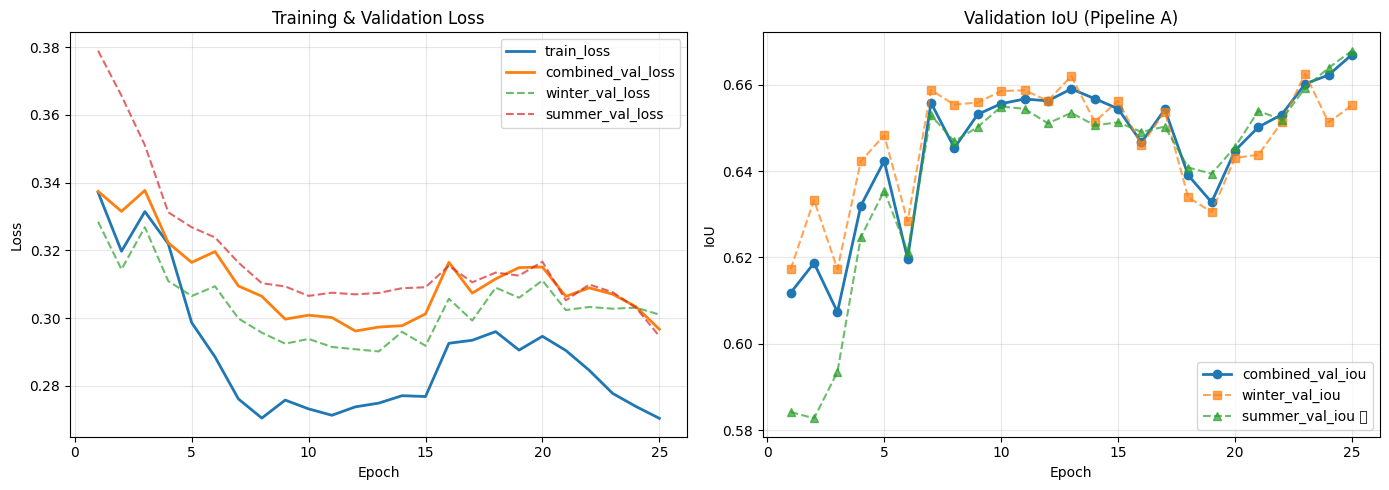

In [21]:
# Plot CSV metrics (now includes combined, winter, and summer validation)
if LOG_CSV.exists():
    df = pd.read_csv(LOG_CSV)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss plot
    axes[0].plot(df['epoch'], df['train_loss'], label='train_loss', linewidth=2)
    if 'val_loss' in df.columns:
        axes[0].plot(df['epoch'], df['val_loss'], label='combined_val_loss', linewidth=2)
    if 'winter_loss' in df.columns:
        axes[0].plot(df['epoch'], df['winter_loss'], label='winter_val_loss', linestyle='--', alpha=0.7)
    if 'summer_loss' in df.columns:
        axes[0].plot(df['epoch'], df['summer_loss'], label='summer_val_loss', linestyle='--', alpha=0.7)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].set_title('Training & Validation Loss')
    axes[0].grid(True, alpha=0.3)
    
    # IoU plot
    if 'val_iou' in df.columns:
        axes[1].plot(df['epoch'], df['val_iou'], label='combined_val_iou', linewidth=2, marker='o')
    if 'winter_iou' in df.columns:
        axes[1].plot(df['epoch'], df['winter_iou'], label='winter_val_iou', linestyle='--', marker='s', alpha=0.7)
    if 'summer_iou' in df.columns:
        axes[1].plot(df['epoch'], df['summer_iou'], label='summer_val_iou ⭐', linestyle='--', marker='^', alpha=0.7)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('IoU')
    axes[1].legend()
    axes[1].set_title('Validation IoU (Pipeline A)')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print('Log CSV not found at', LOG_CSV)

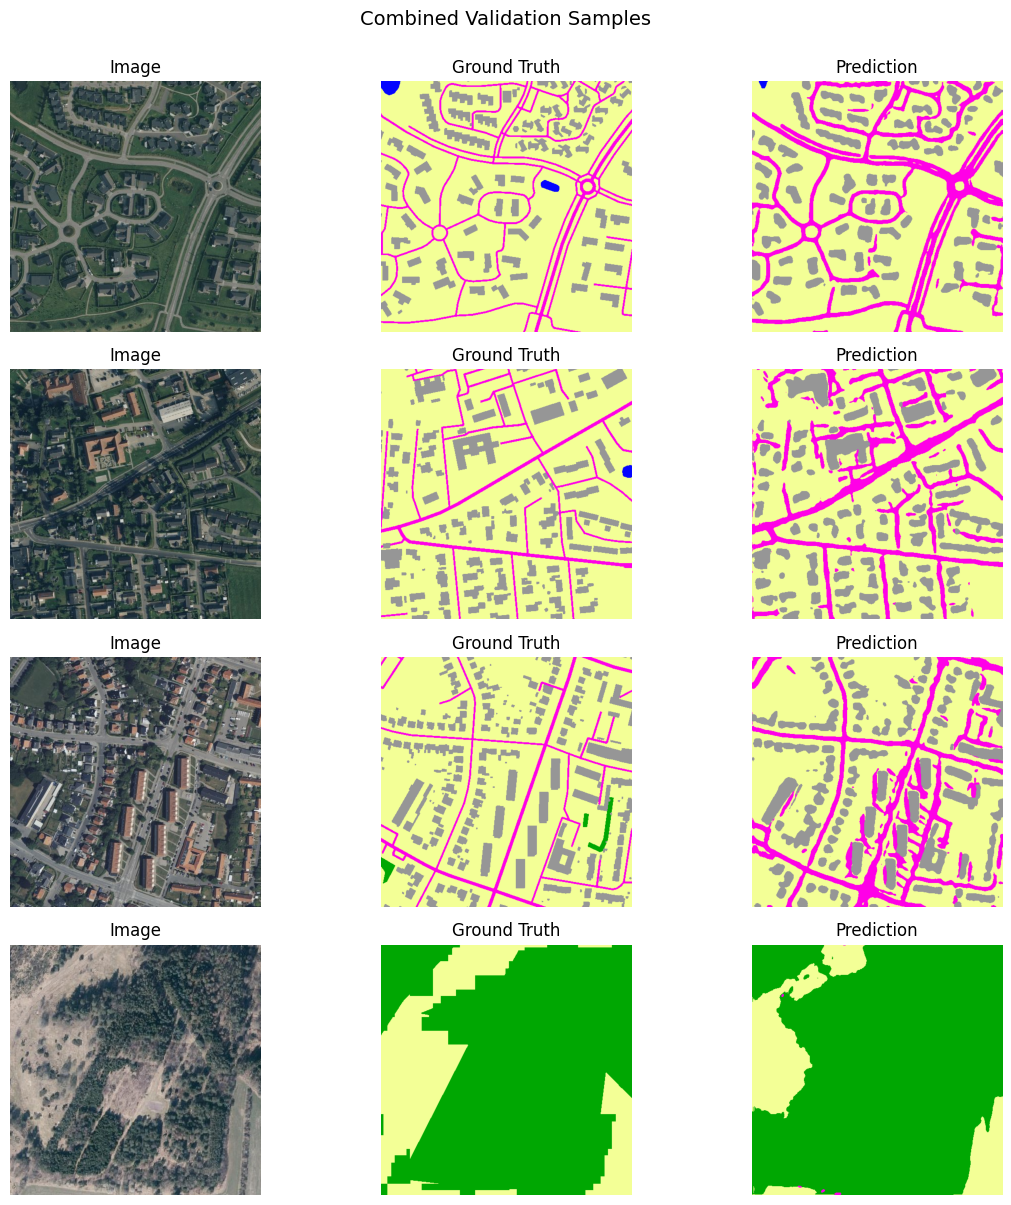

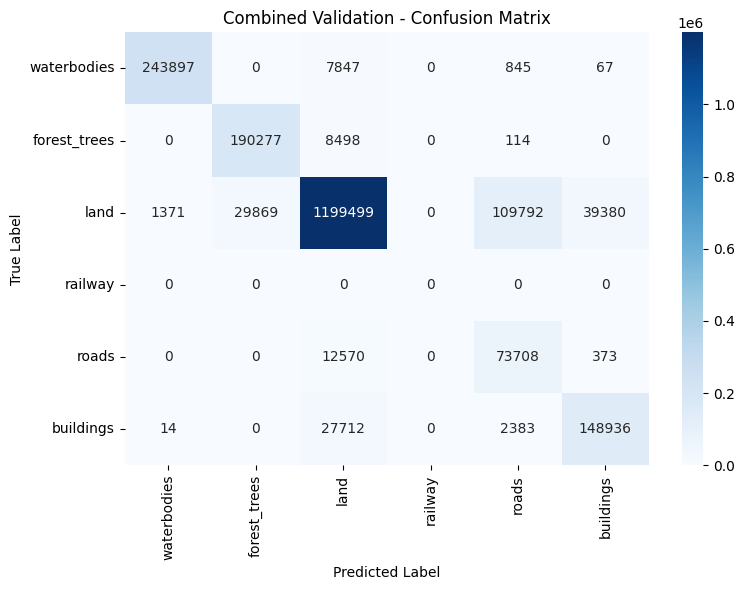

In [22]:
# Confusion matrix and sample visualization
# Choose which validation set to visualize: val_loader (combined), winter_val_loader, or summer_val_loader
VISUALIZE_LOADER = val_loader  # <-- Change to winter_val_loader or summer_val_loader as needed
VISUALIZE_NAME = "Combined"    # <-- Update label: "Combined", "Winter", or "Summer"

model.eval()
sample_imgs, sample_masks = next(iter(VISUALIZE_LOADER))
sample_imgs = sample_imgs.to(device)
with torch.no_grad(): 
    preds = model(sample_imgs)
    preds = torch.argmax(preds, dim=1).cpu().numpy()
sample_masks = sample_masks.cpu().numpy()
sample_imgs = sample_imgs.cpu()

# Denormalize images
mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
std = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
sample_imgs = (sample_imgs * std + mean).permute(0,2,3,1).numpy()
sample_imgs = np.clip(sample_imgs, 0, 1)

# Plot samples
fig, axes = plt.subplots(min(4, len(sample_imgs)), 3, figsize=(12, min(4, len(sample_imgs))*3))
if len(sample_imgs) == 1: 
    axes = axes.reshape(1, -1)
for i in range(min(4, len(sample_imgs))):
    axes[i,0].imshow(sample_imgs[i])
    axes[i,0].axis('off')
    axes[i,0].set_title('Image')
    
    axes[i,1].imshow(decode_segmap(sample_masks[i], COLOR_MAP))
    axes[i,1].axis('off')
    axes[i,1].set_title('Ground Truth')
    
    axes[i,2].imshow(decode_segmap(preds[i], COLOR_MAP))
    axes[i,2].axis('off')
    axes[i,2].set_title('Prediction')
plt.suptitle(f'{VISUALIZE_NAME} Validation Samples', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

# Confusion matrix
cm = confusion_matrix(
    np.concatenate([sample_masks.reshape(-1)]), 
    np.concatenate([preds.reshape(-1)]), 
    labels=list(range(NUM_CLASSES))
)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap='Blues')
plt.title(f'{VISUALIZE_NAME} Validation - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()